# 13 — Statistical Association: Passing Structure vs. Quarterfinal Advancement (2018 World Cup)

**Main question:** Do teams that reached the 2018 quarterfinals show a genuinely different passing-network profile from teams eliminated earlier — and does that signal already show up in the group stage, or is it a knockout-round artifact?

This replicates notebook 05's design (2022) on the 2018 World Cup dataset built in notebook 06, using the exact same feature list, aggregation method, Mann-Whitney settings, rank-biserial formula, and FDR correction, so the two tournaments are directly comparable.

**Two analyses, in order of evidentiary weight:**
1. **Primary — team-level Mann-Whitney U (group stage, one profile per team).** 8 quarterfinalists vs. 24 non-quarterfinalists, 32 independent observations.
2. **Secondary / exploratory — team-match-level Mann-Whitney U** (full tournament, and group-stage only). Retained for match-to-match variation, but not used for the primary conclusion.

**See notebook 14** for the cross-tournament comparison (2018 vs 2022), built from this notebook's and notebook 05's saved team-level results.

**Input:** `data/processed/2018_match_features.csv` + `data/processed/2018_group_stage_team_profiles.csv` (for `reached_qf`)
**Output:** `outputs/tables/mann_whitney_team_level_2018.csv` (primary), `outputs/tables/16_mannwhitney_full_tournament_2018.csv` + `outputs/tables/16_group_stage_qf_comparison_2018.csv` (secondary/exploratory)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

PROC_DIR   = Path('../data/processed')
FIG_DIR    = Path('../outputs/figures')
TABLE_DIR  = Path('../outputs/tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# 2018_match_features.csv (built in notebook 06) has no reached_qf column —
# merge it in from the group-stage team profiles (one row per team, 32 teams).
mf   = pd.read_csv(PROC_DIR / '2018_match_features.csv')
prof = pd.read_csv(PROC_DIR / '2018_group_stage_team_profiles.csv')
df   = mf.merge(prof[['team', 'reached_qf', 'stage_reached']], on='team', how='left')

print(f'Full dataset: {len(df)} rows')
print(f'Rows with missing reached_qf after merge: {df["reached_qf"].isna().sum()}')

# Shared feature list — identical to notebook 05's (2022), used identically
# for the team-level primary analysis and the team-match-level exploratory
# analysis below, so the two tournaments are directly comparable.
COMPARE_COLS = [
    'completed_passes',
    'unique_passing_pairs',
    'network_density',
    'top_player_reliance',
    'final_third_entries',
    'final_third_entries_per_100_passes',
    'connections_per_100_passes',
    'passes_per_connection',
]

Full dataset: 128 rows
Rows with missing reached_qf after merge: 0


## Why the unit of analysis changed

The original analysis treated each team-match as an independent observation. Because every team contributes three group-stage matches, observations from the same team are correlated and therefore do not fully satisfy the independence assumption of the Mann-Whitney U test. For the primary inferential analysis, the three group-stage matches were therefore aggregated into one tournament profile per team. This produces 32 independent team-level observations: 8 quarterfinalists and 24 non-quarterfinalists.

Team-match-level results are retained as exploratory evidence because they preserve match-to-match variation, but statistical inference is based primarily on the team-level analysis.

## Why group-stage-only is the primary analysis

Group-stage matches are used for the primary analysis because every team plays exactly three matches before quarterfinal qualification is known. Using the full tournament would give teams that advance farther more observations, creating unequal weighting and potentially introducing outcome-related selection into the explanatory features.

Therefore: **primary analysis = group stage + team aggregation.** Full-tournament analysis remains available as exploratory evidence (see the secondary section below) but is not the headline statistical test.

## PRIMARY ANALYSIS — Team-Level Mann-Whitney U (2018, Group Stage, One Row per Team)

8 quarterfinalist teams vs. 24 non-quarterfinalist teams, each represented by the mean of its 3 group-stage matches.

In [2]:
# ── Step 2: restrict to group-stage matches and validate ──────────────────
gs = df[df['stage'].str.contains('group', case=False, na=False)].copy()

n_teams           = gs['team'].nunique()
n_rows            = len(gs)
matches_per_team  = gs.groupby('team').size()
n_qf_teams        = gs.loc[gs['reached_qf'] == 1, 'team'].nunique()
n_non_teams       = gs.loc[gs['reached_qf'] == 0, 'team'].nunique()

print('── Group-stage validation ───────────────────────────────────────')
print(f'  Unique teams              : {n_teams}   (expected 32)')
print(f'  Team-match rows           : {n_rows}   (expected 96)')
print(f'  Matches per team (min/max): {matches_per_team.min()} / {matches_per_team.max()}   (expected 3 / 3)')
print(f'  Teams with reached_qf=1   : {n_qf_teams}   (expected 8)')
print(f'  Teams with reached_qf=0   : {n_non_teams}   (expected 24)')
print('────────────────────────────────────────────────────────────────')

assert n_teams == 32, f'Expected 32 unique teams in the group stage, got {n_teams}'
assert n_rows == 96, f'Expected 96 group-stage team-match rows, got {n_rows}'
assert (matches_per_team == 3).all(), 'Not every team has exactly 3 group-stage matches'
assert n_qf_teams == 8, f'Expected 8 quarterfinalist teams, got {n_qf_teams}'
assert n_non_teams == 24, f'Expected 24 non-quarterfinalist teams, got {n_non_teams}'
print('All validation checks passed.')

── Group-stage validation ───────────────────────────────────────
  Unique teams              : 32   (expected 32)
  Team-match rows           : 96   (expected 96)
  Matches per team (min/max): 3 / 3   (expected 3 / 3)
  Teams with reached_qf=1   : 8   (expected 8)
  Teams with reached_qf=0   : 24   (expected 24)
────────────────────────────────────────────────────────────────
All validation checks passed.


In [3]:
# ── Step 3: aggregate the 3 group-stage matches into one profile per team ──
team_profiles = (
    gs
    .groupby(['team', 'reached_qf'])[COMPARE_COLS]
    .mean()
    .reset_index()
)

print('── Team-profile validation ────────────────────────────────────')
print(f'  Total rows     : {len(team_profiles)}   (expected 32)')
print(f'  QF teams       : {(team_profiles["reached_qf"] == 1).sum()}   (expected 8)')
print(f'  Non-QF teams   : {(team_profiles["reached_qf"] == 0).sum()}   (expected 24)')
print(f'  Duplicate teams: {team_profiles["team"].duplicated().sum()}   (expected 0)')
print('──────────────────────────────────────────────────────────────')

assert len(team_profiles) == 32, f'Expected 32 team profiles, got {len(team_profiles)}'
assert (team_profiles['reached_qf'] == 1).sum() == 8
assert (team_profiles['reached_qf'] == 0).sum() == 24
assert team_profiles['team'].duplicated().sum() == 0, 'Duplicate team rows found after aggregation'
print('All validation checks passed. One row per team confirmed.')

team_profiles.round(3)

── Team-profile validation ────────────────────────────────────
  Total rows     : 32   (expected 32)
  QF teams       : 8   (expected 8)
  Non-QF teams   : 24   (expected 24)
  Duplicate teams: 0   (expected 0)
──────────────────────────────────────────────────────────────
All validation checks passed. One row per team confirmed.


,team,reached_qf,completed_passes,unique_passing_pairs,network_density,top_player_reliance,final_third_entries,final_third_entries_per_100_passes,connections_per_100_passes,passes_per_connection
0,Argentina,0,528.667,114.667,0.662,0.169,46.333,8.410,22.523,4.583
1,Australia,0,424.333,101.667,0.559,0.175,31.667,7.293,24.110,4.163
2,Belgium,1,464.000,107.000,0.619,0.151,33.333,7.183,23.437,4.353
3,Brazil,1,562.333,122.333,0.672,0.146,45.333,7.883,22.073,4.580
4,Colombia,0,366.333,107.667,0.622,0.146,33.000,9.103,29.720,3.403
5,Costa Rica,0,287.000,100.000,0.549,0.127,23.667,8.237,35.993,2.830
6,Croatia,1,371.333,99.667,0.548,0.158,30.667,8.250,27.633,3.717
7,Denmark,0,311.333,96.333,0.587,0.142,30.333,9.357,32.283,3.227
8,Egypt,0,332.000,104.667,0.575,0.145,32.333,9.740,31.663,3.167
9,England,1,489.333,113.333,0.691,0.160,38.667,7.857,23.340,4.313


In [4]:
# ── Step 4-6: Mann-Whitney U, rank-biserial correlation, descriptive stats ─
# One test per feature, team level: 8 quarterfinalists vs 24 non-quarterfinalists.
qf_teams  = team_profiles[team_profiles['reached_qf'] == 1]
non_teams = team_profiles[team_profiles['reached_qf'] == 0]

team_rows = []
for col in COMPARE_COLS:
    qf_values  = qf_teams[col].dropna()
    non_values = non_teams[col].dropna()

    stat, p = stats.mannwhitneyu(qf_values, non_values, alternative='two-sided')

    n1, n0 = len(qf_values), len(non_values)
    # rbc > 0: QF teams tend to have larger values. rbc < 0: non-QF teams tend larger.
    rbc = (2 * stat) / (n1 * n0) - 1

    qf_mean, non_mean     = qf_values.mean(), non_values.mean()
    qf_median, non_median = qf_values.median(), non_values.median()
    mean_diff = qf_mean - non_mean
    pct_diff  = (mean_diff / abs(non_mean)) * 100 if non_mean != 0 else np.nan

    team_rows.append({
        'feature':         col,
        'qf_mean':         qf_mean,
        'non_qf_mean':     non_mean,
        'qf_median':       qf_median,
        'non_qf_median':   non_median,
        'mean_difference': mean_diff,
        'pct_difference':  pct_diff,
        'mann_whitney_u':  stat,
        'p_value':         p,
        'rank_biserial':   rbc,
    })

team_results = pd.DataFrame(team_rows)
team_results.round(4)

,feature,qf_mean,non_qf_mean,qf_median,non_qf_median,mean_difference,pct_difference,mann_whitney_u,p_value,rank_biserial
0,completed_passes,415.7500,374.0139,457.8333,362.0000,41.7361,11.1590,121.0,0.2927,0.2604
1,unique_passing_pairs,106.6250,102.8056,107.3333,104.0000,3.8194,3.7152,125.0,0.2147,0.3021
2,network_density,0.6047,0.5892,0.6174,0.5867,0.0155,2.6387,116.0,0.4037,0.2083
3,top_player_reliance,0.1465,0.1474,0.1473,0.1447,-0.0010,-0.6669,104.0,0.7441,0.0833
4,final_third_entries,35.8750,32.4444,36.0000,31.5000,3.4306,10.5736,121.5,0.2763,0.2656
5,final_third_entries_per_100_passes,8.7925,8.8328,8.7283,8.6233,-0.0403,-0.4560,98.0,0.9490,0.0208
6,connections_per_100_passes,27.9700,30.7543,24.4033,30.3300,-2.7843,-9.0534,78.0,0.4540,-0.1875
7,passes_per_connection,3.8354,3.5675,4.1483,3.3700,0.2679,7.5099,114.0,0.4540,0.1875


In [5]:
# ── Step 7: Benjamini-Hochberg FDR correction across the 8 features ───────
team_results['p_fdr'] = multipletests(team_results['p_value'], method='fdr_bh')[1]
team_results['significant_raw'] = team_results['p_value'] < 0.05
team_results['significant_fdr'] = team_results['p_fdr'] < 0.05

team_results[['feature', 'p_value', 'p_fdr', 'significant_raw', 'significant_fdr']].round(4)

,feature,p_value,p_fdr,significant_raw,significant_fdr
0,completed_passes,0.2927,0.6053,False,False
1,unique_passing_pairs,0.2147,0.6053,False,False
2,network_density,0.4037,0.6053,False,False
3,top_player_reliance,0.7441,0.8504,False,False
4,final_third_entries,0.2763,0.6053,False,False
5,final_third_entries_per_100_passes,0.9490,0.9490,False,False
6,connections_per_100_passes,0.4540,0.6053,False,False
7,passes_per_connection,0.4540,0.6053,False,False


In [6]:
# ── Step 8: clean results table, sorted by |rank_biserial| descending ─────
TEAM_RESULT_COLS = [
    'feature', 'qf_mean', 'non_qf_mean', 'qf_median', 'non_qf_median',
    'mean_difference', 'pct_difference', 'mann_whitney_u', 'p_value', 'p_fdr',
    'rank_biserial', 'significant_raw', 'significant_fdr',
]

team_results = (
    team_results[TEAM_RESULT_COLS]
    .assign(_abs_rbc=lambda d: d['rank_biserial'].abs())
    .sort_values('_abs_rbc', ascending=False)
    .drop(columns='_abs_rbc')
    .reset_index(drop=True)
)

team_results.to_csv(TABLE_DIR / 'mann_whitney_team_level_2018.csv', index=False)
print('Saved: outputs/tables/mann_whitney_team_level_2018.csv')

with pd.option_context('display.float_format', lambda x: f'{x:.4f}'):
    print(team_results.to_string())
team_results

Saved: outputs/tables/mann_whitney_team_level_2018.csv
                              feature  qf_mean  non_qf_mean  qf_median  non_qf_median  mean_difference  pct_difference  mann_whitney_u  p_value  p_fdr  rank_biserial  significant_raw  significant_fdr
0                unique_passing_pairs 106.6250     102.8056   107.3333       104.0000           3.8194          3.7152        125.0000   0.2147 0.6053         0.3021            False            False
1                 final_third_entries  35.8750      32.4444    36.0000        31.5000           3.4306         10.5736        121.5000   0.2763 0.6053         0.2656            False            False
2                    completed_passes 415.7500     374.0139   457.8333       362.0000          41.7361         11.1590        121.0000   0.2927 0.6053         0.2604            False            False
3                     network_density   0.6047       0.5892     0.6174         0.5867           0.0155          2.6387        116.0000   0.4037 0

,feature,qf_mean,non_qf_mean,qf_median,non_qf_median,mean_difference,pct_difference,mann_whitney_u,p_value,p_fdr,rank_biserial,significant_raw,significant_fdr
0,unique_passing_pairs,106.625000,102.805556,107.333333,104.000000,3.819444,3.715212,125.0,0.214653,0.605340,0.302083,False,False
1,final_third_entries,35.875000,32.444444,36.000000,31.500000,3.430556,10.573630,121.5,0.276293,0.605340,0.265625,False,False
2,completed_passes,415.750000,374.013889,457.833333,362.000000,41.736111,11.158974,121.0,0.292711,0.605340,0.260417,False,False
3,network_density,0.604700,0.589154,0.617367,0.586717,0.015546,2.638670,116.0,0.403658,0.605340,0.208333,False,False
4,connections_per_100_passes,27.970000,30.754306,24.403333,30.330000,-2.784306,-9.053385,78.0,0.454005,0.605340,-0.187500,False,False
5,passes_per_connection,3.835417,3.567500,4.148333,3.370000,0.267917,7.509928,114.0,0.454005,0.605340,0.187500,False,False
6,top_player_reliance,0.146462,0.147446,0.147300,0.144683,-0.000983,-0.666912,104.0,0.744102,0.850403,0.083333,False,False
7,final_third_entries_per_100_passes,8.792500,8.832778,8.728333,8.623333,-0.040278,-0.456004,98.0,0.949021,0.949021,0.020833,False,False


### Statistical significance vs. effect magnitude (team level, n=32)

**No feature reaches significance, raw or FDR-corrected**, at the team level in 2018 — p-values range from 0.21 to 0.95. That is not the same as "no effect": several features show small-to-moderate directional effects worth noting rather than dismissing outright. `unique_passing_pairs` (rbc=+0.30, p=0.21), `final_third_entries` (rbc=+0.27, p=0.28), and `completed_passes` (rbc=+0.26, p=0.29) all point the same direction as 2022 (QF+ higher) with small-to-moderate magnitude — these are **directional effects that don't clear significance at this sample size**, not proof of zero relationship. The remaining five features (`network_density`, `connections_per_100_passes`, `passes_per_connection`, `top_player_reliance`, `final_third_entries_per_100_passes`) all have |rbc| < 0.21 and are close to negligible.

### Team-level interpretation — 2018

- **Largest QF+/non-QF differences:** `unique_passing_pairs` (rbc=+0.30), `final_third_entries` (rbc=+0.27), `completed_passes` (rbc=+0.26) — small-to-moderate effects, well short of the 2022 magnitudes.
- **Direction:** six of eight features point the same direction as 2022 (QF+ higher passing volume/pairs/density/final-third entries/passes-per-connection, lower connections-per-100-passes); `top_player_reliance` and `final_third_entries_per_100_passes` are essentially flat.
- **Survives FDR correction:** none.
- **Meaningful but not significant:** none clearly clear a ~0.3 "moderate effect" threshold except `unique_passing_pairs` (0.30), which sits right at that boundary.
- **Overall:** at the team level, 2018 shows the same *direction* of association as 2022 for most features, but the *magnitude* is consistently smaller and none of it clears statistical significance with only 8 quarterfinalist teams. This is more consistent with "a weak or underpowered version of the same relationship" than with "no relationship at all," but this analysis alone cannot distinguish those two explanations — it is an association question, not a causal one.

---

## SECONDARY / EXPLORATORY — Team-Match-Level Analysis

**Team-match-level exploratory analysis.** Everything below treats each team-match as its own observation (128 rows for the full tournament, 96 for the group stage). Because each team contributes multiple matches, these observations are not independent, so p-values here are read as descriptive/exploratory, not as the project's primary evidence — see the team-level analysis above for the headline inferential result.

### Part 1 — Full-tournament Mann-Whitney U (team-match level, exploratory)

Non-parametric test (no normality assumption), reported with the rank-biserial correlation
as effect size alongside the p-value. Unit of analysis is one row per team-match (128 rows,
48 from quarterfinalists, 80 from eliminated teams) — rows from the same team are not fully
independent of each other, so this is exploratory evidence, not the primary inferential test.

The feature list is identical to the team-level analysis above (`COMPARE_COLS`).

In [7]:
MW_FEATURES = COMPARE_COLS  # identical feature list to the primary team-level analysis

qf_all  = df[df['reached_qf'] == 1]
non_all = df[df['reached_qf'] == 0]
print(f'QF+ rows: {len(qf_all)}   Eliminated rows: {len(non_all)}')

rows = []
for feat in MW_FEATURES:
    s1 = qf_all[feat].dropna()
    s0 = non_all[feat].dropna()
    stat, p = stats.mannwhitneyu(s1, s0, alternative='two-sided')
    # rbc > 0 means QF+ (s1) tends to rank higher than eliminated (s0); rbc < 0 means lower.
    rbc = (2 * stat) / (len(s1) * len(s0)) - 1
    rows.append({
        'feature': feat,
        'mean_qf': s1.mean(),
        'mean_elim': s0.mean(),
        'effect_size_rbc': rbc,
        'p_value': p,
        'significant': p < 0.05,
    })

mwu_results_2018 = pd.DataFrame(rows).sort_values('p_value').reset_index(drop=True)
mwu_results_2018.to_csv(TABLE_DIR / '13_mannwhitney_full_tournament_2018.csv', index=False)
mwu_results_2018.round(4)

QF+ rows: 48   Eliminated rows: 80


,feature,mean_qf,mean_elim,effect_size_rbc,p_value,significant
0,top_player_reliance,0.1448,0.1475,-0.1107,0.2967,False
1,completed_passes,399.5417,387.3625,0.1003,0.3446,False
2,final_third_entries,34.5208,34.0000,0.0984,0.3533,False
3,passes_per_connection,3.7010,3.6372,0.0906,0.3931,False
4,connections_per_100_passes,29.2479,30.2099,-0.0901,0.3959,False
5,unique_passing_pairs,106.2708,104.3250,0.0852,0.4221,False
6,network_density,0.5934,0.5937,-0.0034,0.9764,False
7,final_third_entries_per_100_passes,8.8821,8.8450,0.0005,0.9980,False


In [8]:
print(f"Significant at p<0.05 (uncorrected, exploratory): "
      f"{int(mwu_results_2018['significant'].sum())} / {len(mwu_results_2018)} features")
print()
for _, r in mwu_results_2018.iterrows():
    pct = (r['mean_qf'] - r['mean_elim']) / r['mean_elim'] * 100 if r['mean_elim'] else float('nan')
    flag = '  <-- significant' if r['significant'] else ''
    print(f"  {r['feature']:<38} QF+ {r['mean_qf']:.2f} vs elim {r['mean_elim']:.2f}  "
          f"({pct:+.1f}%)  p={r['p_value']:.4f}  rbc={r['effect_size_rbc']:.3f}{flag}")

Significant at p<0.05 (uncorrected, exploratory): 0 / 8 features

  top_player_reliance                    QF+ 0.14 vs elim 0.15  (-1.8%)  p=0.2967  rbc=-0.111
  completed_passes                       QF+ 399.54 vs elim 387.36  (+3.1%)  p=0.3446  rbc=0.100
  final_third_entries                    QF+ 34.52 vs elim 34.00  (+1.5%)  p=0.3533  rbc=0.098
  passes_per_connection                  QF+ 3.70 vs elim 3.64  (+1.8%)  p=0.3931  rbc=0.091
  connections_per_100_passes             QF+ 29.25 vs elim 30.21  (-3.2%)  p=0.3959  rbc=-0.090
  unique_passing_pairs                   QF+ 106.27 vs elim 104.33  (+1.9%)  p=0.4221  rbc=0.085
  network_density                        QF+ 0.59 vs elim 0.59  (-0.1%)  p=0.9764  rbc=-0.003
  final_third_entries_per_100_passes     QF+ 8.88 vs elim 8.84  (+0.4%)  p=0.9980  rbc=0.001


**Reading this result (exploratory, team-match level):** unlike 2022, **none of the 8 features reach significance at p<0.05
in the 2018 full-tournament test** — all p-values sit between 0.30 and 1.00, and every
rank-biserial effect size is small (|rbc| < 0.12). The mean differences point in the same
*direction* as 2022 for most metrics, but the gaps are much smaller. This is consistent
with the team-level primary result above — 2018 is null at both units of analysis.

---

## Part 2 — Team-match level, group stage only (exploratory)

Same purpose as the primary group-stage analysis above, computed at the team-match level
for comparison. Repeats the same Mann-Whitney U test, restricted to the group-stage subset.

## 1. Inspect the stage column

In [9]:
print('Unique stage values:')
print(df['stage'].value_counts().to_string())

Unique stage values:
stage
group    96
R16      16
QF        8
SF        4
Final     2
3rd       2


## 2. Filter to group stage

Match any stage label containing "group" (case-insensitive), same filter as notebook 05.

In [10]:
gs = df[df['stage'].str.contains('group', case=False, na=False)].copy()

print('── Validation ───────────────────────────────────────────────')
print(f'  Total rows (all stages)      : {len(df)}')
print(f'  Group-stage rows             : {len(gs)}')
print(f'  Unique matches in group stage: {gs["match_id"].nunique()}')
print(f'  Unique teams in group stage  : {gs["team"].nunique()}')
print()
print(f'  reached_qf = 1 (QF+ teams)  : {(gs["reached_qf"] == 1).sum()} rows  '
      f'({gs[gs["reached_qf"]==1]["team"].nunique()} teams × 3 matches)')
print(f'  reached_qf = 0 (non-QF)     : {(gs["reached_qf"] == 0).sum()} rows  '
      f'({gs[gs["reached_qf"]==0]["team"].nunique()} teams × 3 matches)')
print('─────────────────────────────────────────────────────────────')

── Validation ───────────────────────────────────────────────
  Total rows (all stages)      : 128
  Group-stage rows             : 96
  Unique matches in group stage: 48
  Unique teams in group stage  : 32

  reached_qf = 1 (QF+ teams)  : 24 rows  (8 teams × 3 matches)
  reached_qf = 0 (non-QF)     : 72 rows  (24 teams × 3 matches)
─────────────────────────────────────────────────────────────


## 3. QF+ vs non-QF comparison within the group stage (team-match level)

In [11]:
qf_gs  = gs[gs['reached_qf'] == 1]
non_gs = gs[gs['reached_qf'] == 0]

rows = []
for col in COMPARE_COLS:
    s1 = qf_gs[col].dropna()
    s0 = non_gs[col].dropna()
    qf_mean, non_mean = s1.mean(), s0.mean()
    qf_med, non_med   = s1.median(), s0.median()
    mean_diff = qf_mean - non_mean
    mean_pct  = mean_diff / non_mean * 100 if non_mean else np.nan

    stat, p = stats.mannwhitneyu(s1, s0, alternative='two-sided')
    rbc = (2 * stat) / (len(s1) * len(s0)) - 1

    rows.append({
        'metric':              col,
        'qf_mean':             round(qf_mean,  3),
        'non_qf_mean':         round(non_mean, 3),
        'mean_difference':     round(mean_diff, 3),
        'mean_pct_difference': round(mean_pct,  1),
        'qf_median':           round(qf_med,   3),
        'non_qf_median':       round(non_med,  3),
        'median_difference':   round(qf_med - non_med, 3),
        'effect_size_rbc':     round(rbc, 4),
        'p_value':             round(p, 4),
        'significant':         p < 0.05,
    })

comparison_2018 = pd.DataFrame(rows)
comparison_2018.to_csv(TABLE_DIR / '13_group_stage_qf_comparison_2018.csv', index=False)
print('Saved: outputs/tables/16_group_stage_qf_comparison_2018.csv')
print()
comparison_2018

Saved: outputs/tables/16_group_stage_qf_comparison_2018.csv



,metric,qf_mean,non_qf_mean,mean_difference,mean_pct_difference,qf_median,non_qf_median,median_difference,effect_size_rbc,p_value,significant
0,completed_passes,415.750,374.014,41.736,11.2,434.000,353.500,80.500,0.2216,0.1061,False
1,unique_passing_pairs,106.625,102.806,3.819,3.7,110.500,102.000,8.500,0.2193,0.1095,False
2,network_density,0.605,0.589,0.016,2.6,0.624,0.601,0.023,0.1464,0.2861,False
3,top_player_reliance,0.146,0.147,-0.001,-0.7,0.142,0.148,-0.005,-0.0255,0.8556,False
4,final_third_entries,35.875,32.444,3.431,10.6,34.500,30.000,4.500,0.2060,0.1329,False
5,final_third_entries_per_100_passes,8.792,8.833,-0.040,-0.5,8.830,8.715,0.115,0.0081,0.9561,False
6,connections_per_100_passes,27.970,30.754,-2.784,-9.1,25.310,29.425,-4.115,-0.1979,0.1491,False
7,passes_per_connection,3.835,3.568,0.268,7.5,3.950,3.395,0.555,0.1985,0.1479,False


In [12]:
print('=' * 96)
print(f'  {"Metric":<38}  {"Group QF+":>9}  {"Group Non-QF":>12}  {"Diff":>7}  {"p-value":>8}  {"Sig?"}')
print('=' * 96)
for _, r in comparison_2018.iterrows():
    arrow = '▲' if r['mean_pct_difference'] > 0 else '▼'
    flag  = '✓' if r['significant'] else ''
    print(f'  {r["metric"]:<38}  {r["qf_mean"]:>9.3f}  {r["non_qf_mean"]:>12.3f}  '
          f'{arrow}{abs(r["mean_pct_difference"]):>4.1f}%  {r["p_value"]:>8.4f}  {flag}')
print('=' * 96)

n_sig = int(comparison_2018['significant'].sum())
print(f'\nSignificant at p<0.05 (uncorrected, exploratory): {n_sig} / {len(comparison_2018)} metrics (group stage only, n=32 teams)')

  Metric                                  Group QF+  Group Non-QF     Diff   p-value  Sig?
  completed_passes                          415.750       374.014  ▲11.2%    0.1061  
  unique_passing_pairs                      106.625       102.806  ▲ 3.7%    0.1095  
  network_density                             0.605         0.589  ▲ 2.6%    0.2861  
  top_player_reliance                         0.146         0.147  ▼ 0.7%    0.8556  
  final_third_entries                        35.875        32.444  ▲10.6%    0.1329  
  final_third_entries_per_100_passes          8.792         8.833  ▼ 0.5%    0.9561  
  connections_per_100_passes                 27.970        30.754  ▼ 9.1%    0.1491  
  passes_per_connection                       3.835         3.568  ▲ 7.5%    0.1479  

Significant at p<0.05 (uncorrected, exploratory): 0 / 8 metrics (group stage only, n=32 teams)


## 4. Visualizations (team-match level, exploratory)

/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_75064/1054591680.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_75064/1054591680.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_75064/1054591680.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_75064/1054591680.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matpl

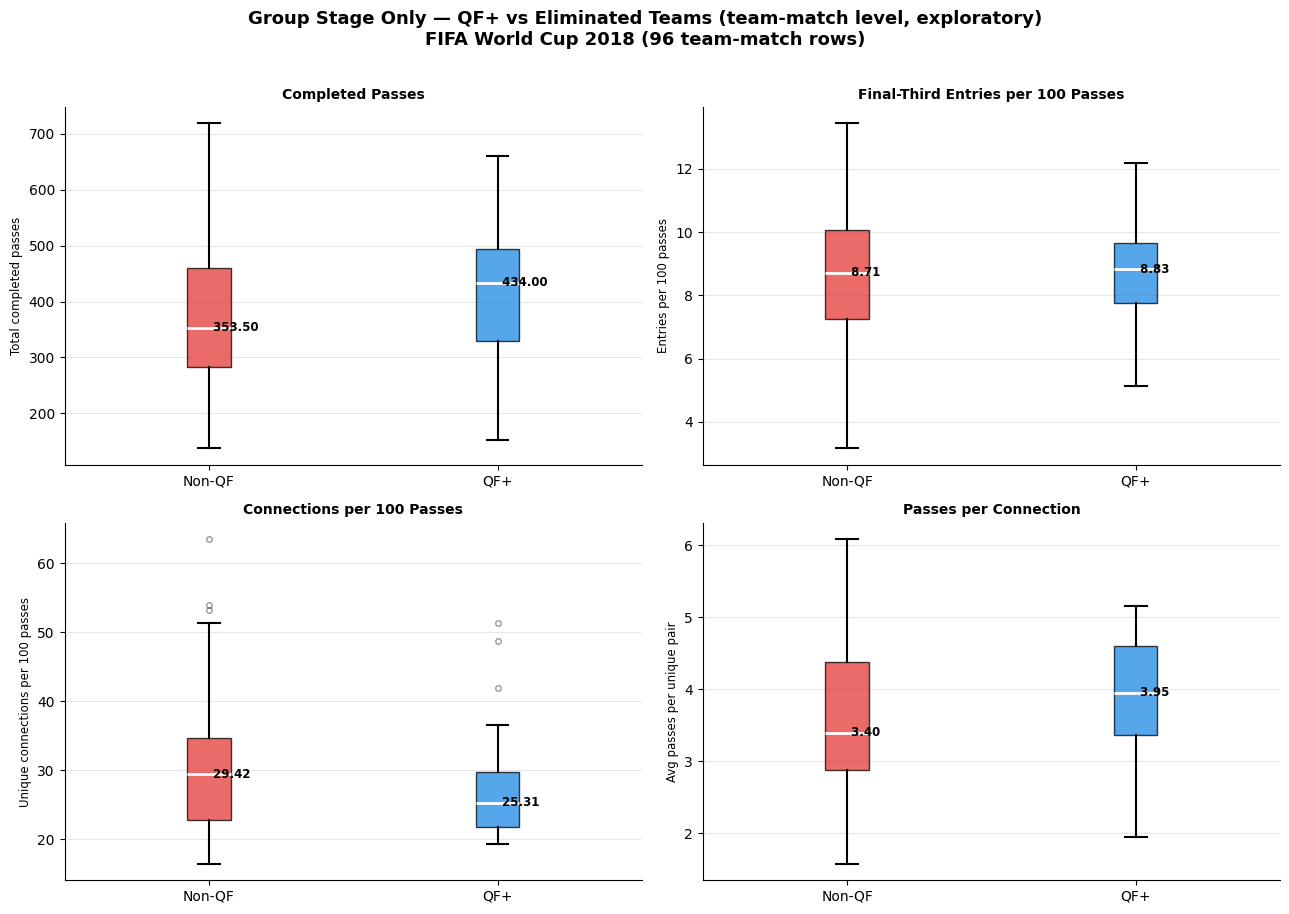

Saved: outputs/figures/16_group_stage_boxplots_2018.png


In [13]:
QF_COLOR  = '#1E88E5'
ELM_COLOR = '#E53935'

def boxplot(ax, col, title, ylabel=None):
    """Single styled boxplot comparing non-QF vs QF+ for a given column."""
    bp = ax.boxplot(
        [non_gs[col].dropna(), qf_gs[col].dropna()],
        labels=['Non-QF', 'QF+'],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=4, alpha=0.4),
    )
    for patch, color in zip(bp['boxes'], [ELM_COLOR, QF_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for i, vals in enumerate([non_gs[col], qf_gs[col]]):
        med = vals.dropna().median()
        ax.text(i + 1, med, f' {med:.2f}', va='center', fontsize=8.5, fontweight='bold')
    ax.set_title(title, fontsize=10, fontweight='bold')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=8.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    'Group Stage Only — QF+ vs Eliminated Teams (team-match level, exploratory)\nFIFA World Cup 2018 (96 team-match rows)',
    fontsize=13, fontweight='bold', y=1.01,
)

boxplot(axes[0, 0], 'completed_passes',
        'Completed Passes', 'Total completed passes')

boxplot(axes[0, 1], 'final_third_entries_per_100_passes',
        'Final-Third Entries per 100 Passes', 'Entries per 100 passes')

boxplot(axes[1, 0], 'connections_per_100_passes',
        'Connections per 100 Passes', 'Unique connections per 100 passes')

boxplot(axes[1, 1], 'passes_per_connection',
        'Passes per Connection', 'Avg passes per unique pair')

plt.tight_layout()
plt.savefig(FIG_DIR / '13_group_stage_boxplots_2018.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/16_group_stage_boxplots_2018.png')

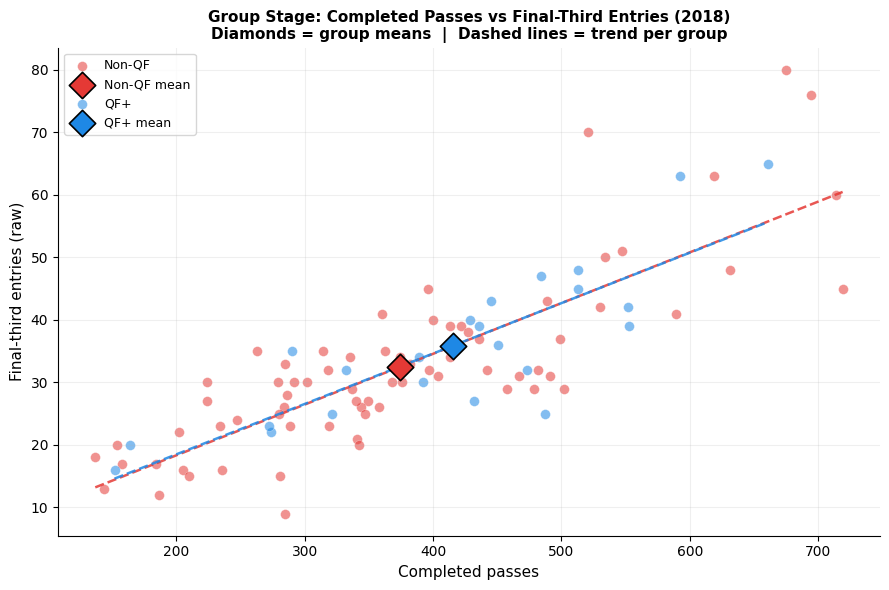

Saved: outputs/figures/16_group_stage_scatter_2018.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 6))

for val, label, color in [(0, 'Non-QF', ELM_COLOR), (1, 'QF+', QF_COLOR)]:
    sub = gs[gs['reached_qf'] == val]
    ax.scatter(
        sub['completed_passes'], sub['final_third_entries'],
        c=color, alpha=0.55, s=50, label=label,
        edgecolors='white', linewidths=0.3,
    )
    sub_clean = sub.dropna(subset=['completed_passes', 'final_third_entries'])
    z = np.polyfit(sub_clean['completed_passes'], sub_clean['final_third_entries'], 1)
    x_line = np.linspace(sub_clean['completed_passes'].min(),
                         sub_clean['completed_passes'].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line),
            color=color, linewidth=1.8, linestyle='--', alpha=0.85)

    ax.scatter(
        sub['completed_passes'].mean(), sub['final_third_entries'].mean(),
        c=color, s=180, marker='D', edgecolors='black', linewidths=1.2,
        zorder=5, label=f'{label} mean',
    )

ax.set_xlabel('Completed passes', fontsize=11)
ax.set_ylabel('Final-third entries (raw)', fontsize=11)
ax.set_title(
    'Group Stage: Completed Passes vs Final-Third Entries (2018)\n'
    'Diamonds = group means  |  Dashed lines = trend per group',
    fontsize=11, fontweight='bold',
)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / '13_group_stage_scatter_2018.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/16_group_stage_scatter_2018.png')

## 5. Interpretation (team-match level, exploratory)

**Note:** this interpretation describes the exploratory, team-match-level results. For the
project's primary inferential conclusion, see the team-level analysis near the top of this
notebook, and the cross-tournament comparison in notebook 14.

### Did QF+ teams still complete more passes during the group stage?

Directionally yes, not significant even at the (inflated-n) team-match level (p=0.106).

### Did QF+ teams still have more raw final-third entries?

Directionally yes, not significant (p=0.133).

### Did QF+ teams have lower or higher final-third entries per 100 passes?

Essentially no difference (p=0.956) — this agrees with 2022, where this metric also failed to reach significance at any unit of analysis.

### Did QF+ teams show more repeated passing relationships (higher passes per connection)?

Directionally yes, not significant (p=0.148).

### Does the group-stage analysis support or weaken the 2018 full-tournament result?

It is **consistent** with it: neither the full-tournament nor the group-stage-only test — at
either the team-match or team level — finds a significant passing-network difference between
2018 QF+ and eliminated teams.

The group-stage-only, team-match-level results agree with the 2018 team-level primary
analysis: directional trends resemble 2022, but nothing reaches significance in 2018 at any
unit of analysis. **See notebook 14** for the cross-tournament comparison, built from the
corrected team-level results in both this notebook and notebook 05.